# Clustering methods - comprehensive study

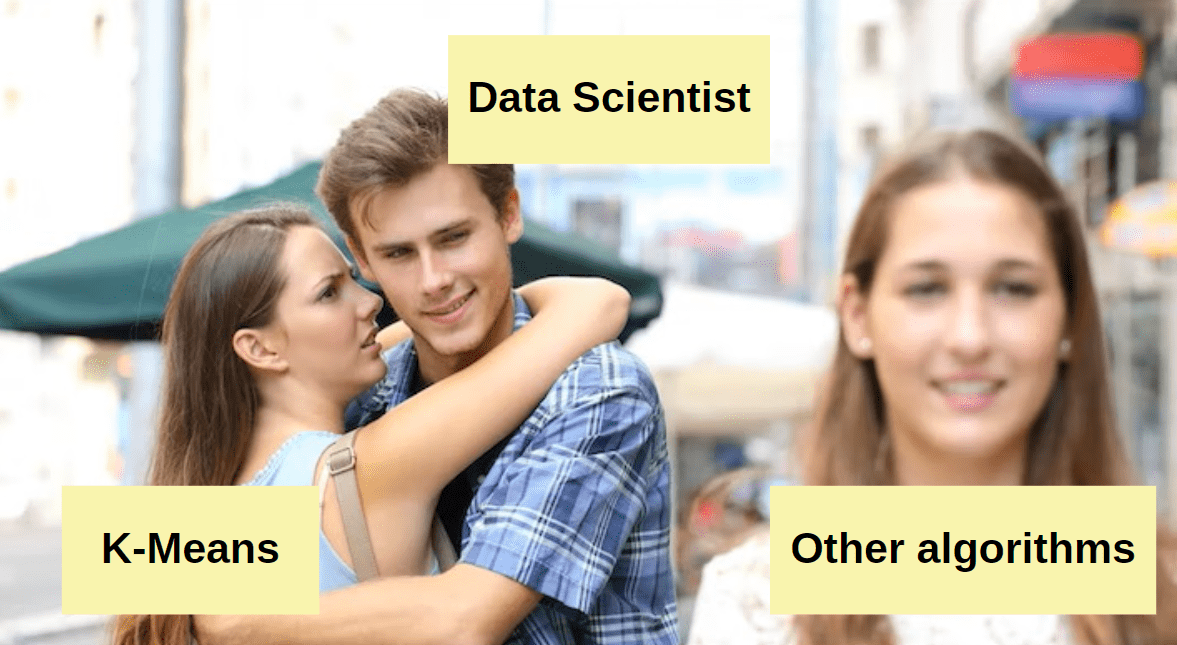

# Introduction

Clustering is one of the most frequently used forms of unsupervised learning. It automatically discover natural grouping in data.

Clustering is especially useful for exploring data you know nothing about. You might find connections you never would have thought of. Clustering can also be useful as a type of feature engineering, where existing and new examples can be mapped and labeled as belonging to one of the identified clusters in the data.

Some typical real world applications of clustering include fraud detection, categorizing books in a library or customer segmentation in marketing.


## Table of Contents
* 1. Types of clustering algorithms
* 2. Set-up
    * 2.1 Data sets
    * 2.2 Import Libraries
    * 2.3 Import Data
    * 2.4 Some Visualisations
    * 2.5 Feature engineering
    * 2.6 Outlier detection
    * 2.7 Scalling data
* 3. Determining The Optimal Number Of Clusters
    * 3.1 Elbow method
    * 3.2 Silhouette method
    * 3.3 Dendrogram
* 4. K-Means
    * 4.1 Advantages and disadvantages of K-Means
    * 4.2 Variations of K-Means
    * 4.3 Training the K-Means model on the datasets
    * 4.4 Comparing results
    * 4.5 K-Means on online retail data
* 5. Hierarchical clustering
    * 5.1 Advantages and Disadvantages of Hierarchical clustering
    * 5.2 Variations of hierarchical clustering
    * 5.3 Training the hierarchical clustering model on the datasets
    * 5.4 Comparing results
    * 5.5 Hierarchical clustering on online retail data
* 6. DBSCAN clustering algorithm
    * 6.1 Advantages and Disadvantages of DBSCAN
    * 6.2 Choosing the right initial parameters
    * 6.3 Variations of DBSCAN
    * 6.4 Training of DBSCAN clustering model on the datasets
    * 6.5 Comparing results
    * 6.6 DBSCAN clustering model on online retail data
* 7. Gaussian Mixture Models (GMM)
    * 7.1 Advantages and Disadvantages of Gaussian Mixture Models
    * 7.2 Variations of GMM
    * 7.3 Training of GMM on the datasets
    * 7.4 Comparing results
    * 7.5 GMM clustering model on online retail data
* 8. All algorithm comparison

# 1. Types of clustering algorithms

There are many clustering algorithms to choose. It is a good idea to explore a range of clustering algorithms and different configurations. It might take some time to figure out which type of clustering algorithm works the best for the given data, but when you do, you'll get invaluable insight on your data.

**Centroid-based**

* These types of algorithms separate data points based on multiple centroids in the data. Each data point is assigned to a cluster based on its squared distance from the centroid. 

* This is the most commonly used type of clustering. K-Means algorithm is one of the centroid based clustering algorithms. Here k is the number of clusters and is a hyperparameter to the algorithm.

**Hierarchical-based (Connectivity-based)**

* The idea is based on the core idea of objects being more related to nearby objects than to objects farther away. 
* It builds a tree of clusters so everything is organized from the top-down. Initially each data point is considered as an individual cluster. At each iteration, the similar clusters merge with other clusters until one cluster or K clusters are formed.

**Density-based**

* Data is grouped by areas of high concentrations of data points surrounded by areas of low concentrations of data points. Basically the algorithm finds the places that are dense with data points and calls those clusters.

* The clusters can be any shape. You aren't constrained to expected conditions.

* The clustering algorithms under this type don't try to assign outliers to clusters, so they get ignored.

**Distribution-based**

* It is a clustering model in which we will fit the data on the probability that how it may belong to the same distribution.
* There is a center-point established. As the distance of a data point from the center increases, the probability of it being a part of that cluster decreases. 

* This model works well on synthetic data and diversely sized clusters. 

* The method suffers from overfitting, unless constraints are put on the model complexity. A more complex model will usually be able to explain the data better, which makes choosing the appropriate model complexity inherently difficult.

# 2. Set-up

### 2. 1 Data sets

I decided to use 7 data sets. Six for exercise visualisations and one for solving real-data problem. 

Exercises sets:
https://www.kaggle.com/datasets/joonasyoon/clustering-exercises

Real-data set:
https://www.kaggle.com/datasets/shrutipandit707/onlineretaildata

### 2.2 Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from collections import Counter

%matplotlib inline

### 2.3 Import Data

In [ ]:
blob_df = pd.read_csv("../input/clustering-exercises/blob.csv")
dart_df = pd.read_csv("../input/clustering-exercises/dart.csv")
outliers_df = pd.read_csv("../input/clustering-exercises/outliers.csv")
spiral2_df = pd.read_csv("../input/clustering-exercises/spiral2.csv")
basic2_df = pd.read_csv("../input/clustering-exercises/basic2.csv")
boxes3_df = pd.read_csv("../input/clustering-exercises/boxes3.csv")

raw_df = pd.read_csv("../input/onlineretaildata/Online_Retail.csv", encoding= 'unicode_escape')

### 2.4 Some Visualisations

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3,figsize=(13,13))
fig.suptitle('EXERCISE DATA SETS\n', size = 18)

axes[0,0].scatter(blob_df['x'], blob_df['y'], c=blob_df['color'], s=10, cmap = "Set3")
axes[0,0].set_title("Blob");

axes[0,1].scatter(dart_df['x'], dart_df['y'], c=dart_df['color'], s=10, cmap = "Set3")
axes[0,1].set_title("Dart");

axes[0,2].scatter(basic2_df['x'], basic2_df['y'], c=basic2_df['color'], s=10, cmap = "Set3")
axes[0,2].set_title("Basic");

axes[1,0].scatter(outliers_df['x'], outliers_df['y'], c=outliers_df['color'], s=10, cmap = "Set3")
axes[1,0].set_title("Outliers");

axes[1,1].scatter(spiral2_df['x'], spiral2_df['y'], c=spiral2_df['color'], s=10, cmap = "Set3")
axes[1,1].set_title("Spiral");

axes[1,2].scatter(boxes3_df['x'], boxes3_df['y'], c=boxes3_df['color'], s=10, cmap = "Set3")
axes[1,2].set_title("Boxes");

plt.tight_layout()

### 2.5 Feature engineering

The real-life data need some preparation before clustering.

In [ ]:
raw_df.describe(include='all')

In [ ]:
# dropping columns
raw_df.drop(['StockCode', 'InvoiceDate','Description','Country'],axis = 1, inplace =True)

In [ ]:
print(raw_df["Quantity"].min())
print(raw_df["UnitPrice"].min())

Negative values probably mean that there were returns. This is important factor for e-commerce, but for this study let's keep only transactions without return (our goal is to introduce and compare different clustering methods).

In [ ]:
df = raw_df.loc[raw_df["Quantity"] >0 ]
df = df.loc[df["UnitPrice"] >0 ]

In [ ]:
print(df["Quantity"].min())
print(df["UnitPrice"].min())

In [ ]:
# creating a new column of Total amount
df["Total"]=df["Quantity"]*df["UnitPrice"]

In [ ]:
# dropping 'Quantity' and 'UnitPrice'
df.drop(['Quantity', 'UnitPrice'],axis = 1, inplace =True)

In [ ]:
# Checking data for the missing values
df.isnull().sum()

In [ ]:
# Dropping the missing value in customerId .
df.dropna(axis = 0, inplace=True)

**Creating new features:**

1. Frequency: total number of transactions

2. Amount: total amount of transactions

In [ ]:
#Amount
Amount = df.groupby('CustomerID')['Total'].sum()
Amount = Amount.reset_index()
Amount.columns=['CustomerID','Amount']

#frequency
Frequency=df.groupby('CustomerID')['InvoiceNo'].count()
Frequency=Frequency.reset_index()
Frequency.columns=['CustomerID','Frequency']

# merge both df
df1 = pd.merge(Amount, Frequency, on='CustomerID', how='inner')
df1.head()

In [ ]:
# dropping 'CustomerID'
df1.drop(['CustomerID'],axis = 1, inplace =True)

### 2.6 Outlier detection

In [ ]:
df1.describe(include='all')

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(6,6))
fig.suptitle('Outliers\n', size = 25)

sns.boxplot(ax=axes[0], data=df1['Amount'], palette='Spectral').set_title("Amount")
sns.boxplot(ax=axes[1], data=df1['Frequency'], palette='Spectral').set_title("Frequency")

plt.tight_layout()

It looks like we have significant problem with outliers.

#### Outlier detection model  selection
* distribution is not normal
* distribution is highly skewed
* we have huge outliers

Isolation Forest does not assume normal distribution and is able to detect outliers at a multi-dimensional level. Isolation Forest is also computationally efficient. The algorithm is based on the principle that anomalies are observations that are few and different, this should make them easier to identify. That's why I choose Isolation Forest.

For oulier detection methods look here:
https://www.kaggle.com/code/marcinrutecki/outlier-detection-methods

In [ ]:
from sklearn.ensemble import IsolationForest
df2 = df1.copy()

In [ ]:
# Model building
model=IsolationForest(n_estimators=150, max_samples='auto', contamination=float(0.1), max_features=1.0)
model.fit(df2)

In [ ]:
# Adding 'scores' and 'anomaly' colums to df
scores=model.decision_function(df2)
anomaly=model.predict(df2)

df2['scores']=scores
df2['anomaly']=anomaly

anomaly = df2.loc[df2['anomaly']==-1]
anomaly_index = list(anomaly.index)
print('Total number of outliers is:', len(anomaly))

In [ ]:
# dropping outliers
df2 = df2.drop(anomaly_index, axis = 0).reset_index(drop=True)

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(6,6))
fig.suptitle('Outliers\n', size = 25)

sns.boxplot(ax=axes[0], data=df2['Amount'], palette='Spectral').set_title("Amount")
sns.boxplot(ax=axes[1], data=df2['Frequency'], palette='Spectral').set_title("Frequency")

plt.tight_layout()

We can see that Isolation Forest algorithm did well!

In [ ]:
# dropping columns that we don't need any more
df2.drop(['scores', 'anomaly'], axis = 1, inplace =True)

### 2.7 Scalling data

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df3=scaler.fit_transform(df2)

# 3. Determining The Optimal Number Of Clusters

Selecting optimal number of clusters is key to applying clustering algorithm to the dataset, such as k-means clustering, which requires the user to specify the number of clusters k to be generated. This is a somewhat arbitrary procedure, one of the weakest aspects of performing cluster analysis.

The major difference between **elbow** and **silhouette method** is that elbow only calculates the euclidean distance whereas silhouette takes into account variables such as variance, skewness, high-low differences, etc. 

Both the Elbow method / SSE Plot and the Silhouette method can be used interchangeably based on the details presented by the plots. 

### 3.1 Elbow method

Elbow method is a heuristic used in determining the number of clusters in a data set. The method consists of plotting the explained variation as a function of the number of clusters and picking the elbow of the curve as the number of clusters to use.

The elbow method is a graphical representation of finding the optimal 'K' in a K-means clustering. It works by finding WCSS (Within-Cluster Sum of Square) i.e. the sum of the square distance between points in a cluster and the cluster centroid.

The optimal number of clusters can be defined as follow:

* Compute clustering algorithm (e.g., k-means clustering) for different values of k. For instance, by varying k from 1 to 10 clusters.
* For each k, calculate the total within-cluster sum of square (WSS).
* Plot the curve of wss according to the number of clusters k.
* The location of a bend (knee) in the plot is generally considered as an indicator of the appropriate number of clusters.

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(df3)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
from yellowbrick.cluster import KElbowVisualizer
model = KMeans()
# k is range of number of clusters.
visualizer = KElbowVisualizer(model, k=(2,30), timings= True)
visualizer.fit(df3)        # Fit data to visualizer
visualizer.show()        # Finalize and render figure

### 3.2 Silhouette method

Average silhouette approach measures the **quality of a clustering**. That is, it determines how well each object lies within its cluster. A high average silhouette width indicates a good clustering. The optimal number of clusters k is the one that maximize the average silhouette over a range of possible values for k (Kaufman and Rousseeuw 1990).

The algorithm can be computed as follow:

* Compute clustering algorithm (e.g., k-means clustering) for different values of k.
* For each k, calculate the average silhouette of observations (avg.sil).
* Plot the curve of avg.sil according to the number of clusters k.
* The location of the maximum is considered as the appropriate number of clusters.

The silhouette score falls within the range [-1, 1].

The silhouette score of 1 means that the clusters are very dense and nicely separated. The score of 0 means that clusters are overlapping. The score of less than 0 means that data belonging to clusters may be wrong/incorrect.


In [ ]:
from sklearn import datasets
from sklearn.metrics import silhouette_score

# Instantiate the KMeans for 5 clusters
km = KMeans(n_clusters=5, random_state=42)
# Fit the KMeans model
km.fit_predict(df3)
# Calculate Silhoutte Score
score = silhouette_score(df3, km.labels_, metric='euclidean')
# Print the score
print('Silhouetter Average Score: %.3f' % score)

In [ ]:
from yellowbrick.cluster import SilhouetteVisualizer

# Yellowbrick extends the Scikit-Learn API to make model selection and hyperparameter tuning easier.
# You can find the code to simply create Silhouette visualisation for K-Means clusters with n_cluster as 2, 3, 4, 5, 6, 7 below.

fig, ax = plt.subplots(3, 2, figsize=(13,8))
fig.suptitle('Silhouette Analysis for 2-7 Clusters', size = 18)
plt.tight_layout()

for i in [2, 3, 4, 5, 6, 7]:
    '''
    Create KMeans instance for different number of clusters
    '''
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=42)
    q, mod = divmod(i, 2)
    '''
    Create SilhouetteVisualizer instance with KMeans instance
    Fit the visualizer
    '''
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q-1][mod])
    visualizer.fit(df3)

The choice here is not so obvious due to the following reasons:

1. Presence of clusters with below average silhouette scores for 5-7 clusters.
2. Wide fluctuations in the size of the silhouette plots.
3. The fluctuation in size is not similar, but better for 6 and 7 clusters.
4. The thickness of the silhouette plot representing each cluster also is a deciding point. Unfortunately we have one cluster which is significantly thicker than the others.

### 3.3 Dendrogram

This technique is specific to the agglomerative hierarchical method of clustering. The method starts by considering each point as a separate cluster and starts joining points to clusters in a hierarchical fashion based on their distances. To get the optimal number of clusters for hierarchical clustering, we make use a dendrogram which is tree-like chart that shows the sequences of merges or splits of clusters.

In [ ]:
import scipy.cluster.hierarchy as sch
from matplotlib import pyplot
pyplot.figure(figsize=(12, 5))
dendrogram = sch.dendrogram(sch.linkage(df3, method = 'ward'))
plt.title('Dendrogram')
plt.ylabel('Euclidean distances')
plt.show()

# 4. K-Means

K-Means Clustering may be the most widely known clustering algorithm and involves assigning examples to clusters in an effort to minimize the variance within each cluster.
It's a centroid-based algorithm and the simplest unsupervised learning algorithm.
The algorithm tries to minimize the variance of data points within a cluster. It's also how most people are introduced to unsupervised machine learning.

**K-means++** (default init parameter for K-Means in sklearn) is the algorithm which is used to overcome the drawback posed by the k-means algorithm. The goal is to spread out the initial centroid by assigning the first centroid randomly then selecting the rest of the centroids based on the maximum squared distance. The idea is to push the centroids as far as possible from one another.

Although the initialization in K-means++ is computationally more expensive than the standard K-means algorithm, the run-time for convergence to optimum is drastically reduced for K-means++. This is because the centroids that are initially chosen are likely to lie in different clusters already.

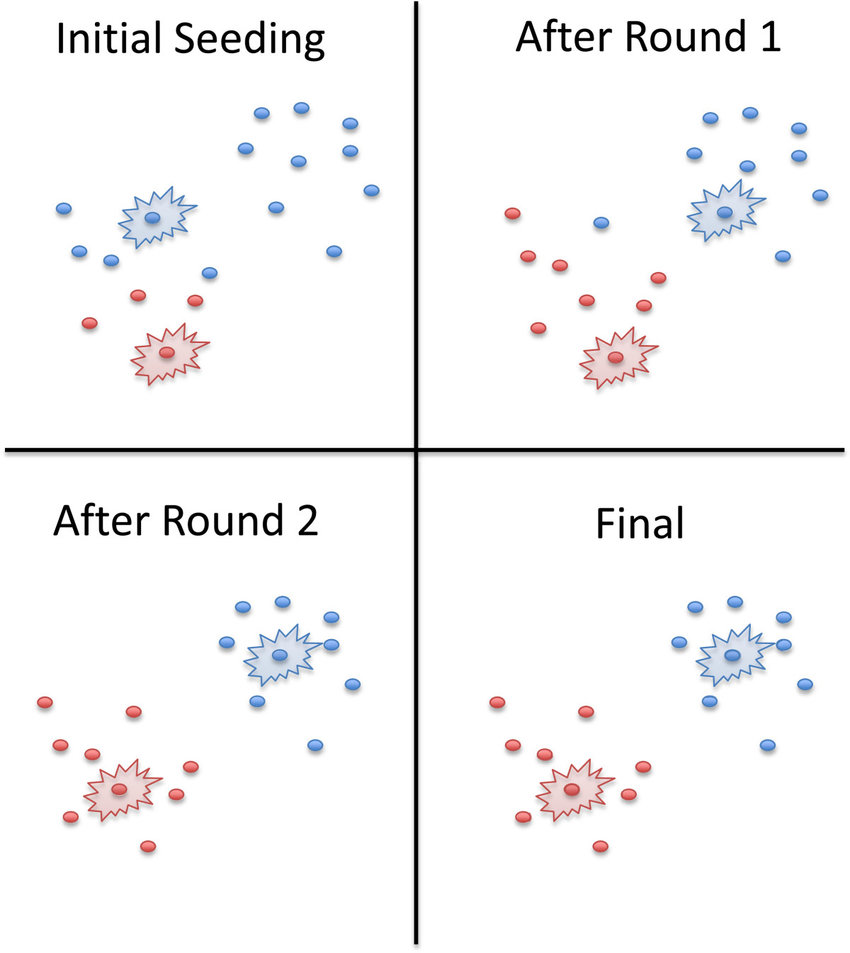

### 4.1 Advantages and disadvantages of K-Means

**Advantages of K-Means clustering:**

1. **Simple** - It is easy to implement

2. **High Performance** - K-Means clustering technique is fast and efficient in terms of its computational cost

4. **Easy to interpret** - K-Means returns clusters which can be easily interpreted and visualized

5. **Suitable for large data sets** while clustering algorithms are known to be relatively slow, the k-means algorithm is comparatively fast, that's why it's effective for large data sets.


**Disadvantages of K-Means clustering:**

1. **Assumes spherical density** - this means that k-means clustering does not perform as well in situations where clusters naturally have irregular shapes. This is a relatively strict assumption.

2. **Sensitive to scale** - if one of the variables is on a much larger scale than the others that variable will have an outsized effect on the distance calculated. This means that we generally need to re-scale data before using k-means clustering.

3. **Difficult to incorporate categorical variables** - K-means is intended to be used when all of your features are numeric. There are ways you can adapt your data to be suitable if you have some categorical features, but in general the majority of your features should be numeric.

4. **Sensitive to outliers** - K-Means has no no outlier detection method. Centroids can be dragged by outliers, or outliers might get their own cluster instead of being ignored. 

5. **Initialization sensitivity** - K-means clustering is sensitive to the starting conditions that are used to initialize the algorithm such as the choice of seed or the order of the data points. If we get unlucky with a choice of starting points, the clusters produced can be arbitrarily bad. This one gets fixed with a variant known as k-means++ (default init for sklearn)

6. **Have to choose the number of clusters** - K-means clustering requires to specify the number of clusters that will be created ahead of time. Picking the right value of 'k' is a challenging model selection problem. 

7. **Struggles with high dimensional data** - The algorithm depends on Euclidean distance, which is pretty bad in high dimensions. If we have many potential features, we should consider applying feature selection or dimensionality reduction algorithms to the data before creating clusters.

8. **The algorithm is randomized** - which means that we can run it on the same data set multiple times and get different answers. This is a big issue for a lot of applications.

9. **k-means can only separate clusters that are more or less linearly separable** - If your clusters are based on distance to the origin, k-means won’t be able to identify them. We can fix that by switching to polar coordinates.

**The ways to avoid the problem of initialization sensitivity in k-means algorithm:**

1. **Repeat k-means** - the algorithm is executed repeatedly. The centroids are initialized and the clusters are formed to result in smallest intra-cluster distance and larger inter-cluster distance.

2. **K-Means++** - a smart centroid initialization technique. Only one centroid is initialized randomly, and other centroids are chosen such that they are very far from the initial centroid/s. This results in faster convergence and lower possibility of the centroid being poorly initialized. Default init for sklearn.

K means++ provides comparatively better results.

### 4.2 Variations of K-Means

**Some of the variations of the k-means algorithm:**

1. **k-medians clustering** - uses the median in each dimension (instead of the mean).

2. **k-medoids (Partitioning Around Medoids)** - uses medoid instead of mean, and minimizes the sum of distances for arbitrary distance functions.

3. **Fuzzy C-Means clustering** - a soft version of k-means, where each data point has a fuzzy degree of belonging to each cluster.

4. **k-means++** - standard k-means algorithm with a smarter initialization of the centroids (default init for sklearn).

### 4.3 Training the K-Means model on the datasets

In [ ]:
# Copying data sets
df_kmeans = df3.copy()
df_blob_kmeans = blob_df.copy()
df_dart_kmeans = dart_df.copy()
df_basic_kmeans = basic2_df.copy()
df_outliers_kmeans = outliers_df.copy()
df_spiral2_kmeans = spiral2_df.copy()
df_boxes3_kmeans = boxes3_df.copy()

In [ ]:
df_blob_kmeans.drop(['color'], axis = 1, inplace =True)
df_dart_kmeans.drop(['color'], axis = 1, inplace =True)
df_basic_kmeans.drop(['color'], axis = 1, inplace =True)
df_outliers_kmeans.drop(['color'], axis = 1, inplace =True)
df_spiral2_kmeans.drop(['color'], axis = 1, inplace =True)
df_boxes3_kmeans.drop(['color'], axis = 1, inplace =True)

In [ ]:
# Training model
kmeans = KMeans(n_clusters = 6, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(df_kmeans)

kmeans_blob = KMeans(n_clusters = 4, init = 'k-means++', random_state = 42)
kmeans_dart = KMeans(n_clusters = 2, init = 'k-means++', random_state = 42)
kmeans_basic = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
kmeans_outliers = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
kmeans_spiral2 = KMeans(n_clusters = 2, init = 'k-means++', random_state = 42)
kmeans_boxes3 = KMeans(n_clusters = 12, init = 'k-means++', random_state = 42)

y_kmeans_blob = kmeans_blob.fit_predict(df_blob_kmeans)
y_kmeans_dart = kmeans_dart.fit_predict(df_dart_kmeans)
y_kmeans_basic = kmeans_basic.fit_predict(df_basic_kmeans)
y_kmeans_outliers = kmeans_outliers.fit_predict(df_outliers_kmeans)
y_kmeans_spiral2 = kmeans_spiral2.fit_predict(df_spiral2_kmeans)
y_kmeans_boxes3 = kmeans_boxes3.fit_predict(df_boxes3_kmeans)

In [ ]:
# Creating 'Cluster' columns in data sets
df_blob_kmeans['Cluster'] = y_kmeans_blob
df_dart_kmeans['Cluster'] = y_kmeans_dart
df_basic_kmeans['Cluster'] = y_kmeans_basic
df_outliers_kmeans['Cluster'] = y_kmeans_outliers
df_spiral2_kmeans['Cluster'] = y_kmeans_spiral2
df_boxes3_kmeans['Cluster'] = y_kmeans_boxes3

### 4.4 Comparing results

In [ ]:
fig, axes = plt.subplots(nrows=6, ncols=2,figsize=(10,30))
fig.suptitle('ANSWER vs K-Means\n', size = 18)

axes[0,0].scatter(blob_df['x'], blob_df['y'], c=blob_df['color'], s=10, cmap = "Set3")
axes[0,0].set_title("Answer Blob");
axes[0,1].scatter(df_blob_kmeans['x'], df_blob_kmeans['y'], c=df_blob_kmeans['Cluster'], s=10, cmap = "Set3")
axes[0,1].set_title("K-Means Blob");

axes[1,0].scatter(dart_df['x'], dart_df['y'], c=dart_df['color'], s=10, cmap = "Set3")
axes[1,0].set_title("Answer Dart");
axes[1,1].scatter(df_dart_kmeans['x'], df_dart_kmeans['y'], c=df_dart_kmeans['Cluster'], s=10, cmap = "Set3")
axes[1,1].set_title("K-Means Dart");

axes[2,0].scatter(basic2_df['x'], basic2_df['y'], c=basic2_df['color'], s=10, cmap = "Set3")
axes[2,0].set_title("Answer Basic");
axes[2,1].scatter(df_basic_kmeans['x'], df_basic_kmeans['y'], c=df_basic_kmeans['Cluster'], s=10, cmap = "Set3")
axes[2,1].set_title("K-Means Basic");

axes[3,0].scatter(outliers_df['x'], outliers_df['y'], c=outliers_df['color'], s=10, cmap = "Set3")
axes[3,0].set_title("Answer Outliers");
axes[3,1].scatter(df_outliers_kmeans['x'], df_outliers_kmeans['y'], c=df_outliers_kmeans['Cluster'], s=10, cmap = "Set3")
axes[3,1].set_title("K-Means Outliers");

axes[4,0].scatter(spiral2_df['x'], spiral2_df['y'], c=spiral2_df['color'], s=10, cmap = "Set3")
axes[4,0].set_title("Answer Spiral");
axes[4,1].scatter(df_spiral2_kmeans['x'], df_spiral2_kmeans['y'], c=df_spiral2_kmeans['Cluster'], s=10, cmap = "Set3")
axes[4,1].set_title("K-Means Spiral");

axes[5,0].scatter(boxes3_df['x'], boxes3_df['y'], c=boxes3_df['color'], s=10, cmap = "Set3")
axes[5,0].set_title("Answer Boxes");
axes[5,1].scatter(df_boxes3_kmeans['x'], df_boxes3_kmeans['y'], c=df_boxes3_kmeans['Cluster'], s=10, cmap = "Set3")
axes[5,1].set_title("K-Means Boxes");

plt.tight_layout()

### 4.5 K-Means on online retail data

In [ ]:
# We called the df, that's why we need to refer to previous df to add cluster numbers
df_kmeans = df2.copy()
# Checking number of items in clusters and creating 'Cluster' column
df_kmeans['Cluster'] = y_kmeans
df_kmeans['Cluster'].value_counts()

In [ ]:
plt.figure(figsize=(15,7))
sns.scatterplot(data=df_kmeans, x='Amount', y='Frequency', hue = 'Cluster', s=15, palette="Set3")

# 5. Hierarchical clustering
Hierarchical clustering (also called hierarchical cluster analysis or HCA) is a method of cluster analysis that seeks to build a hierarchy of clusters. It's used to group objects in clusters based on how similar they are to each other. In general, the merges and splits are determined in a greedy manner. The results of hierarchical clustering are usually presented in a dendrogram.

Hierarchical clustering is particularly useful in situations where you have a few observations you are particularly interested in and you want to be able to identify observations that are similar to those observations.

**Hierarchical clustering can be**:

**Agglomerative** – it starts with an individual element and then groups them into single clusters.

**Divisive** – it starts with a complete dataset and divides it into partitions.

Agglomerative clustering is best at finding small clusters. The end result looks like a dendrogram so that you can easily visualize the clusters when the algorithm finishes.

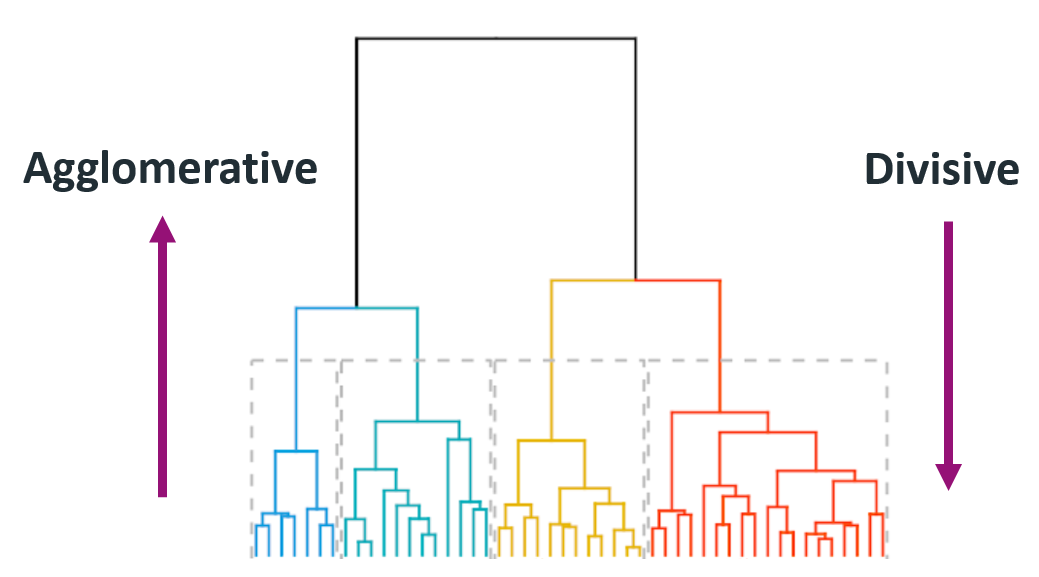

### 5.1 Advantages and Disadvantages of Hierarchical clustering

**Advantages of Hierarchical clustering:**

1. **Get the most similar observations to any given observations** - the algorithm provides detailed information about which observations are most similar to each other. This level of detail is not provided by many other algorithms. 

2. **Not so sensitive to initialization conditions** - it is not sensitive to initialization conditions such as seeds that are set or the order of the dataset. You should generally get very similar results, and in some cases the same exact result, if you re-run your analysis with different initialization conditions.

3. **Can be adapted to incorporate categorical variables** - it can be adapted to support situations where you have a mixture of numeric and categorical variables relatively easily. In order to do this, you must ensure that you are using a distance metrics that is appropriate for mixed data types such as Grower’s distance.

4. **Less sensitive to outliers** - the presence of a few outliers is not likely to affect the way the algorithm performs on the other data points.

5. **Less stringent assumptions about cluster shape** - algorithms do not make as stringent assumptions about the shape of your clusters. Depending on the distance metric you use, some cluster shapes may be detected more easily than others, but there is more flexibility.


**Disadvantages of Hierarchical clustering:**


1. **Relatively slow** - it is a mathematically very heavy algorithm. Hierarchical clustering generally requires to compute the pairwise distance between all of the observations in a dataset, so the number of computations required grows rapidly as the size of your dataset increases.

2. **Have to specify the number of clusters** - but the number of clusters can be changed after the main part of the algorithm has run, so we can experiment with using different numbers of clusters without having to run the algorithm from scratch.

3. **Sensitive to scale** - we may need to rescale data before running clustering. The exact level of sensitivity will vary depending on what distance metric we are using to calculate the distance between points.

4. **Heavily driven by heuristics** - this leads to a lot of manual intervention in the process and consequently, application/domain-specific knowledge is required to analyze whether the result makes any sense or not.

5. **Possibly difficult to visualize** - If the number of data samples increases, then visually analyzing dendrogram and making decisions becomes impossible.

### 5.2 Variations of hierarchical clustering

**BIRCH** is an extension of hierarchical clustering that runs faster on large datasets. It has lower memory requirements than standard hierarchical clustering.

### 5.3 Training the hierarchical clustering model on the datasets

In [ ]:
# Copying data sets
df_AgglomerativeC = df3.copy()
df_blob_AgglomerativeC = blob_df.copy()
df_dart_AgglomerativeC = dart_df.copy()
df_basic2_AgglomerativeC = basic2_df.copy()
df_outliers_AgglomerativeC = outliers_df.copy()
df_spiral2_AgglomerativeC = spiral2_df.copy()
df_boxes3_AgglomerativeC = boxes3_df.copy()

In [ ]:
df_blob_AgglomerativeC.drop(['color'], axis = 1, inplace =True)
df_dart_AgglomerativeC.drop(['color'], axis = 1, inplace =True)
df_basic2_AgglomerativeC.drop(['color'], axis = 1, inplace =True)
df_outliers_AgglomerativeC.drop(['color'], axis = 1, inplace =True)
df_spiral2_AgglomerativeC.drop(['color'], axis = 1, inplace =True)
df_boxes3_AgglomerativeC.drop(['color'], axis = 1, inplace =True)

In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Training model
AgglomerativeC = AgglomerativeClustering(n_clusters=6, affinity = 'euclidean', linkage = 'ward')
y_AgglomerativeC = AgglomerativeC.fit_predict(df_AgglomerativeC)

AgglomerativeC_blob = AgglomerativeClustering(n_clusters = 4, affinity = 'euclidean', linkage = 'ward')
AgglomerativeC_dart = AgglomerativeClustering(n_clusters = 2, affinity = 'euclidean', linkage = 'ward')
AgglomerativeC_basic = AgglomerativeClustering(n_clusters = 5, affinity = 'euclidean', linkage = 'ward')
AgglomerativeC_outliers = AgglomerativeClustering(n_clusters = 3, affinity = 'euclidean', linkage = 'ward')
AgglomerativeC_spiral2 = AgglomerativeClustering(n_clusters = 2, affinity = 'euclidean', linkage = 'ward')
AgglomerativeC_boxes3 = AgglomerativeClustering(n_clusters = 12, affinity = 'euclidean', linkage = 'ward')

y_AgglomerativeC_blob = AgglomerativeC_blob.fit_predict(df_blob_AgglomerativeC)
y_AgglomerativeC_dart = AgglomerativeC_dart.fit_predict(df_dart_AgglomerativeC)
y_AgglomerativeC_basic = AgglomerativeC_basic.fit_predict(df_basic2_AgglomerativeC)
y_AgglomerativeC_outliers = AgglomerativeC_outliers.fit_predict(df_outliers_AgglomerativeC)
y_AgglomerativeC_spiral2 = AgglomerativeC_spiral2.fit_predict(df_spiral2_AgglomerativeC)
y_AgglomerativeC_boxes3 = AgglomerativeC_boxes3.fit_predict(df_boxes3_AgglomerativeC)

In [ ]:
# Creating 'Cluster' columns in data sets
df_blob_AgglomerativeC['Cluster'] = y_AgglomerativeC_blob
df_dart_AgglomerativeC['Cluster'] = y_AgglomerativeC_dart
df_basic2_AgglomerativeC['Cluster'] = y_AgglomerativeC_basic
df_outliers_AgglomerativeC['Cluster'] = y_AgglomerativeC_outliers
df_spiral2_AgglomerativeC['Cluster'] = y_AgglomerativeC_spiral2
df_boxes3_AgglomerativeC['Cluster'] = y_AgglomerativeC_boxes3

### 5.4 Comparing results

In [ ]:
fig, axes = plt.subplots(nrows=6, ncols=2,figsize=(10,30))
fig.suptitle('ANSWER vs Hierarchical clustering\n', size = 18)

axes[0,0].scatter(blob_df['x'], blob_df['y'], c=blob_df['color'], s=10, cmap = "Set3")
axes[0,0].set_title("Answer Blob");
axes[0,1].scatter(df_blob_AgglomerativeC['x'], df_blob_AgglomerativeC['y'], c=df_blob_AgglomerativeC['Cluster'], s=10, cmap = "Set3")
axes[0,1].set_title("Hierarchical clustering Blob");

axes[1,0].scatter(dart_df['x'], dart_df['y'], c=dart_df['color'], s=10, cmap = "Set3")
axes[1,0].set_title("Answer Dart");
axes[1,1].scatter(df_dart_AgglomerativeC['x'], df_dart_AgglomerativeC['y'], c=df_dart_AgglomerativeC['Cluster'], s=10, cmap = "Set3")
axes[1,1].set_title("Hierarchical clustering Dart");

axes[2,0].scatter(basic2_df['x'], basic2_df['y'], c=basic2_df['color'], s=10, cmap = "Set3")
axes[2,0].set_title("Answer Basic");
axes[2,1].scatter(df_basic2_AgglomerativeC['x'], df_basic2_AgglomerativeC['y'], c=df_basic2_AgglomerativeC['Cluster'], s=10, cmap = "Set3")
axes[2,1].set_title("Hierarchical clustering Basic");

axes[3,0].scatter(outliers_df['x'], outliers_df['y'], c=outliers_df['color'], s=10, cmap = "Set3")
axes[3,0].set_title("Answer Outliers");
axes[3,1].scatter(df_outliers_AgglomerativeC['x'], df_outliers_AgglomerativeC['y'], c=df_outliers_AgglomerativeC['Cluster'], s=10, cmap = "Set3")
axes[3,1].set_title("Hierarchical clustering Outliers");

axes[4,0].scatter(spiral2_df['x'], spiral2_df['y'], c=spiral2_df['color'], s=10, cmap = "Set3")
axes[4,0].set_title("Answer Spiral");
axes[4,1].scatter(df_spiral2_AgglomerativeC['x'], df_spiral2_AgglomerativeC['y'], c=df_spiral2_AgglomerativeC['Cluster'], s=10, cmap = "Set3")
axes[4,1].set_title("Hierarchical clustering Spiral");

axes[5,0].scatter(boxes3_df['x'], boxes3_df['y'], c=boxes3_df['color'], s=10, cmap = "Set3")
axes[5,0].set_title("Answer Boxes");
axes[5,1].scatter(df_boxes3_AgglomerativeC['x'], df_boxes3_AgglomerativeC['y'], c=df_boxes3_AgglomerativeC['Cluster'], s=10, cmap = "Set3")
axes[5,1].set_title("Hierarchical clustering Boxes");

plt.tight_layout()

### 5.5 Hierarchical clustering on online retail data

In [ ]:
# We called the df, that's why we need to refer to previous df to add cluster numbers
df_AgglomerativeC = df2.copy()
# Checking number of items in clusters and creating 'Cluster' column
df_AgglomerativeC['Cluster'] = y_AgglomerativeC
df_AgglomerativeC['Cluster'].value_counts()

In [ ]:
plt.figure(figsize=(15,7))
sns.scatterplot(data=df_AgglomerativeC, x='Amount', y='Frequency', hue = 'Cluster', s=15, palette="Set3")

# 6. DBSCAN clustering algorithm
DBSCAN stands for density-based spatial clustering of applications with noise. It's a density-based clustering algorithm.
It is able to find irregular-shaped clusters. It separates regions by areas of low-density so it can also detect outliers really well. This algorithm is better than k-means when it comes to working with oddly shaped data.

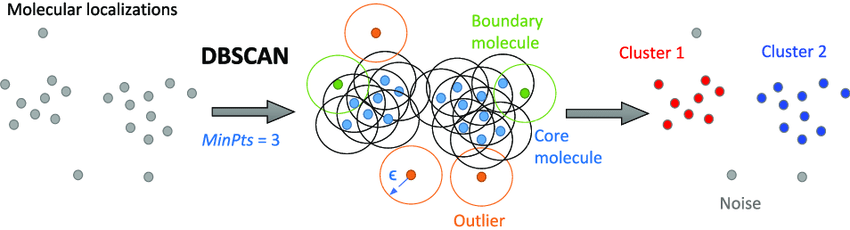

### 6.1 Advantages and Disadvantages of DBSCAN

**Advantages of DBSCAN:**
1. **Handles irregularly shaped and sized clusters** - DBSCAN is one of the algorithms that makes the fewest assumptions about the shape of clusters. That means that DBSCAN can be used to detect clusters that are oddly or irregularly shaped.

2. **Robust to outliers** - the algorithm it is able to detect outliers and exclude them from the clusters entirely. 

3. **Does not require the number of clusters to be specified** - another advantage of DBSCAN is that it does not require the user to specify the number of clusters. DBSCAN can automatically detect the number of clusters that exist in the data. This is great for cases where you do not have much intuition on how many clusters there should be.

4. **Less sensitive to initialization conditions** - DBSCAN is less sensitive to initialization conditions like the order of the observations in the dataset and the seed that is used than some other clustering algorithms.

5. **Relatively fast** - DBSCAN is generally slower than K-Means clustering, but faster than hierarchical clustering and spectral clustering.


**Disadvantages of DBSCAN:**
1. **Difficult to incorporate categorical features** - you should use DBSCAN in cases where most of your features are numeric.

2. **Requires a drop in density to detect cluster borders** - there must be a drop in the density of the data points between clusters in order for the algorithm to be able to detect the boundaries between clusters. If there are multiple clusters that are overlapping without a drop in data density between them, they may get grouped into a single cluster.

3. **Struggles with clusters of varying density** - DBSCAN determines where clusters start and stop by looking at places where the density of data points drops below a certain threshold. It may be difficult to find a threshold that captures all of the points in the less dense cluster without excluding too many extraneous outliers in the more dense cluster.

4. **Sensitive to scale** - DBSCAN is sensitive to the scale of variables. That means that we need to rescale variables if they are on very different scales.

5. **Struggles with high dimensional data** - performance of DBSCAN tends to degrade in situations where there are many features. We should use dimensionality reduction or features selection techniques to reduce the number of features if we have a high-dimensional dataset.

6. **Need to set-up parameters for Epsilon and MinPts**. This could be tricky.



### 6.2 Choosing the right initial parameters

DBSCAN requires two parameters - choosing the right numbers is critical for this algorithm:

1. **Epsilon (ε)** is the radius of the circle to be created around each data point to check the density.

This technique calculates the average distance between each point and its k nearest neighbors, where k = the MinPts value you selected. The average k-distances are then plotted in ascending order on a k-distance graph. The value of **epsilon** can be decided from the K-distance graph. The point of maximum curvature (elbow) in this graph tells us about the value of epsilon (i.e. where the graph has the greatest slope).


2. **minPoints (MinPts)** is the minimum number of data points required inside that circle for that data point to be classified as a Core point.

There is no automatic way to determine the MinPts value for DBSCAN. It does not make sense to take minPoints as 1 because it will result in each point being a separate cluster. Therefore, it must be at least 3. Generally, it is twice the dimensions or dimensions +1. Domain knowledge also decides its value.

* If the data set is noisier, choose a larger value of MinPts
* For 2-dimensional data, use DBSCAN’s default value of MinPts = 4 (Ester et al., 1996).

The value of minPoints should be at least one greater than the number of dimensions of the dataset:

* MinPts >= Dimensions * 2

OR

* MinPts >= Dimensions + 1

**IMPORTANT:**

Sometimes it is difficult to find suitable parameters of Epsilon and MinPts for data set. These are some hints:

1. Use a larger MinPts for large and noisy data sets.

2. If you get too large clusters: decrease epsilon.

3. If you get too much noise: increase epsilon). 

4. Good clustering requires iterations.

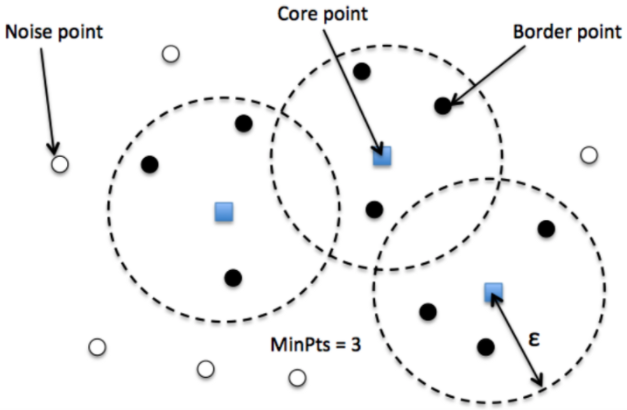

For plotting a K-distance Graph, we need a distance between a point and its nearest data point for all data points in the dataset. We obtain this using NearestNeighbors from sklearn.neighbors.

In [ ]:
# Copying data sets
df_DBScan = df3.copy()
df_blob_DBScan = blob_df.copy()
df_dart_DBScan = dart_df.copy()
df_basic2_DBScan = basic2_df.copy()
df_outliers_DBScan = outliers_df.copy()
df_spiral2_DBScan = spiral2_df.copy()
df_boxes3_DBScan = boxes3_df.copy()

In [ ]:
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=4)
nbrs = nn.fit(df_dart_DBScan)
distances, indices = nbrs.kneighbors(df_dart_DBScan)

# Plotting K-distance Graph
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.figure(figsize=(6,6))
plt.plot(distances)
plt.title('K-distance Graph for "Dart df"',fontsize=20)
plt.xlabel('Data Points sorted by distance',fontsize=14)
plt.ylabel('Epsilon',fontsize=14)
plt.show()

1. The optimum value of epsilon is at the point of maximum curvature in the K-Distance Graph, which is 8 in this case.
2. For MinPts I'll choose 4 (2 * dimensions)

### 6.3 Variations of DBSCAN

**Generalized DBSCAN (GDBSCAN)** - the ε and minPts parameters are removed from the original algorithm and moved to the predicates.

**OPTICS (Ordering Points To Identify the Clustering Structure)** - finds core sample of high density and expands clusters from them. Unlike DBSCAN, keeps cluster hierarchy for a variable neighborhood radius. Better suited for usage on large datasets than the current sklearn implementation of DBSCAN.

**HDBSCAN** - hierarchical version of DBSCAN which is also faster than OPTICS, from which a flat partition consisting of the most prominent clusters can be extracted from the hierarchy.

DBSCAN is also used as part of subspace clustering algorithms like PreDeCon and SUBCLU. 

### 6.4 Training of DBSCAN clustering model on the datasets

In [ ]:
df_blob_DBScan.drop(['color'], axis = 1, inplace =True)
df_dart_DBScan.drop(['color'], axis = 1, inplace =True)
df_basic2_DBScan.drop(['color'], axis = 1, inplace =True)
df_outliers_DBScan.drop(['color'], axis = 1, inplace =True)
df_spiral2_DBScan.drop(['color'], axis = 1, inplace =True)
df_boxes3_DBScan.drop(['color'], axis = 1, inplace =True)

In [ ]:
# Training model
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=20, min_samples=9, metric='euclidean')
y_DBScan = dbscan.fit_predict(df_DBScan)

DBScan_blob = DBSCAN(eps=13, min_samples=45, metric='euclidean')
DBScan_dart = DBSCAN(eps=8, min_samples=4, metric='euclidean')
DBScan_basic = DBSCAN(eps=15, min_samples=4, metric='euclidean')
DBScan_outliers = DBSCAN(eps=20, min_samples=4, metric='euclidean')
DBScan_spiral2 = DBSCAN(eps=5.7, min_samples=4, metric='euclidean')
DBScan_boxes3 = DBSCAN(eps=6, min_samples=4, metric='euclidean')

y_DBScan_blob = DBScan_blob.fit_predict(df_blob_DBScan)
y_DBScan_dart = DBScan_dart.fit_predict(df_dart_DBScan)
y_DBScan_basic = DBScan_basic.fit_predict(df_basic2_DBScan)
y_DBScan_outliers = DBScan_outliers.fit_predict(df_outliers_DBScan)
y_DBScan_spiral2 = DBScan_spiral2.fit_predict(df_spiral2_DBScan)
y_DBScan_boxes3 = DBScan_boxes3.fit_predict(df_boxes3_DBScan)

In [ ]:
# Creating 'Cluster' columns in data sets
df_blob_DBScan['Cluster'] = y_DBScan_blob
df_dart_DBScan['Cluster'] = y_DBScan_dart
df_basic2_DBScan['Cluster'] = y_DBScan_basic
df_outliers_DBScan['Cluster'] = y_DBScan_outliers
df_spiral2_DBScan['Cluster'] = y_DBScan_spiral2
df_boxes3_DBScan['Cluster'] = y_DBScan_boxes3

### 6.5 Comparing results

In [ ]:
fig, axes = plt.subplots(nrows=6, ncols=2,figsize=(10,30))
fig.suptitle('ANSWER vs DBSCAN clustering\n', size = 18)

axes[0,0].scatter(blob_df['x'], blob_df['y'], c=blob_df['color'], s=10, cmap = "Set3")
axes[0,0].set_title("Answer Blob");
axes[0,1].scatter(df_blob_DBScan['x'], df_blob_DBScan['y'], c=df_blob_DBScan['Cluster'], s=10, cmap = "Set3")
axes[0,1].set_title("DBSCAN clustering Blob");

axes[1,0].scatter(dart_df['x'], dart_df['y'], c=dart_df['color'], s=10, cmap = "Set3")
axes[1,0].set_title("Answer Dart");
axes[1,1].scatter(df_dart_DBScan['x'], df_dart_DBScan['y'], c=df_dart_DBScan['Cluster'], s=10, cmap = "Set3")
axes[1,1].set_title("DBSCAN clustering Dart");

axes[2,0].scatter(basic2_df['x'], basic2_df['y'], c=basic2_df['color'], s=10, cmap = "Set3")
axes[2,0].set_title("Answer Basic");
axes[2,1].scatter(df_basic2_DBScan['x'], df_basic2_DBScan['y'], c=df_basic2_DBScan['Cluster'], s=10, cmap = "Set3")
axes[2,1].set_title("DBSCAN clustering Basic");

axes[3,0].scatter(outliers_df['x'], outliers_df['y'], c=outliers_df['color'], s=10, cmap = "Set3")
axes[3,0].set_title("Answer Outliers");
axes[3,1].scatter(df_outliers_DBScan['x'], df_outliers_DBScan['y'], c=df_outliers_DBScan['Cluster'], s=10, cmap = "Set3")
axes[3,1].set_title("DBSCAN clustering Outliers");

axes[4,0].scatter(spiral2_df['x'], spiral2_df['y'], c=spiral2_df['color'], s=10, cmap = "Set3")
axes[4,0].set_title("Answer Spiral");
axes[4,1].scatter(df_spiral2_DBScan['x'], df_spiral2_DBScan['y'], c=df_spiral2_DBScan['Cluster'], s=10, cmap = "Set3")
axes[4,1].set_title("DBSCAN clustering Spiral");

axes[5,0].scatter(boxes3_df['x'], boxes3_df['y'], c=boxes3_df['color'], s=10, cmap = "Set3")
axes[5,0].set_title("Answer Boxes");
axes[5,1].scatter(df_boxes3_DBScan['x'], df_boxes3_DBScan['y'], c=df_boxes3_DBScan['Cluster'], s=10, cmap = "Set3")
axes[5,1].set_title("DBSCAN clustering Boxes");

plt.tight_layout()

### 6.6 DBSCAN clustering model on online retail data

In [ ]:
# We called the df, that's why we need to refer to previous df to add cluster numbers
df_DBScan = df2.copy()
# Checking number of items in clusters and creating 'Cluster' column
df_DBScan['Cluster'] = y_DBScan
df_DBScan['Cluster'].value_counts()

In [ ]:
plt.figure(figsize=(15,7))
sns.scatterplot(data=df_DBScan, x='Amount', y='Frequency', hue = 'Cluster', s=15, palette="Set3")

# 7. Gaussian Mixture Models (GMM) 
A Gaussian mixture model (GMM) attempts to find a mixture of multi-dimensional Gaussian probability distributions that best model any input dataset. In the simplest case, GMMs can be used for finding clusters in the same manner as k-means, but because GMM contains a probabilistic model under the hood, it is also possible to find probabilistic cluster assignments.

The Gaussian mixture model uses multiple Gaussian distributions to fit arbitrarily shaped data.

There are several single Gaussian models that act as hidden layers in this hybrid model. So the model calculates the probability that a data point belongs to a specific Gaussian distribution and that's the cluster it will fall under.




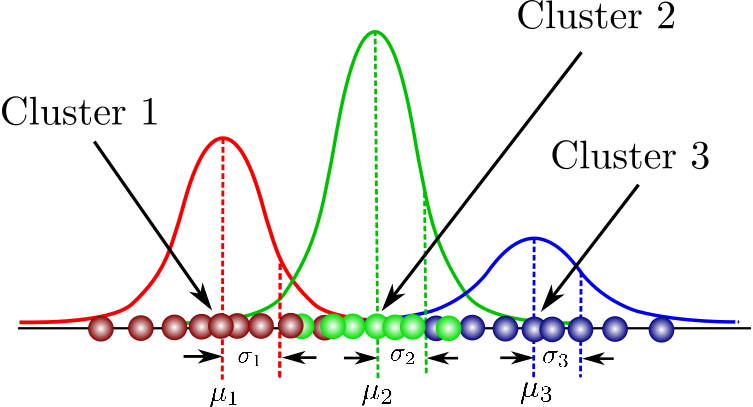

### 7.1 Advantages and Disadvantages of Gaussian Mixture Models

**Advantages of Gaussian Mixture Models (GMM):**
1. **Probabilistic estimates of belonging to each cluster** - models provide estimates of the probability that each data point belongs to each cluster. These probability estimates can be very useful when examining ambiguous data points that fall at the border of two clusters.

2. **Does not assume spherical clusters** - model do not assume that all clusters are uniformly shaped spheres. Instead, gaussian mixture models can be used to accommodate clusters of varying shapes.

3. **Handles clusters of differing sizes** gaussian mixture models can also be used to accommodate clusters of varying sizes.

4. **Less sensitive to scale** - that means that you may not need to rescale your variables before using them for clustering.

5. **Accommodates mixed membership** - in kmeans, a point belongs to one and only one cluster, whereas in GMM a point belongs to each cluster to a different degree. The degree is based on the probability of the point being generated from each cluster’s (multivariate) normal distribution, with cluster center as the distribution’s mean and cluster covariance as its covariance. Depending on the task, mixed membership may be more appropriate (e.g. news articles can belong to multiple topic clusters) or not (e.g. organisms can belong to only one species).


**Disadvantages of Gaussian Mixture Model (GMM):**
1. **Difficult to incorporate categorical features** - models operate under the assumption that all of your features are normally distributed, so they are not easily adapted to categorical data.

2. **Assumes a normal distribution for features** - this means that you should take some time to look at the distributions of features before reaching for this clustering algorithm.

3. **Make some assumptions about cluster shape** - this means that gaussian mixture models will not perform as well in cases where clusters are very irregularly shaped.

4. **Needs sufficient data for each cluster** - you should make sure that you have enough data points in each cluster to adequately estimate the covariance. The amount of data required is not huge, but it is larger than simple algorithms that do not estimate a covariance matrix.

5. **Need to specify number of clusters** - since gaussian mixture models operate under the assumption that your features are normally distributed, they can be thrown off by cases where there are many outliers in the data. Some implementations of gaussian mixture models allow for outliers to be separated out into a separate cluster.

6. **Sensitive to initialization conditions** - Gsuch as the seed that is used and the starting points that are used for cluster centers. This means you may get different results if you run the algorithm multiple times.

7. **Slow** - this is especially true when there are many features in your dataset.

### 7.2 Variations of GMM

 **Variational Bayesian Gaussian mixture** - avoids the specification of the number of components for a Gaussian mixture model.

### 7.3 Training of GMM on the datasets

In [ ]:
# Copying data sets
df_GMM = df3.copy()
df_blob_GMM = blob_df.copy()
df_dart_GMM = dart_df.copy()
df_basic2_GMM = basic2_df.copy()
df_outliers_GMM = outliers_df.copy()
df_spiral2_GMM = spiral2_df.copy()
df_boxes3_GMM = boxes3_df.copy()

In [ ]:
df_blob_GMM.drop(['color'], axis = 1, inplace =True)
df_dart_GMM.drop(['color'], axis = 1, inplace =True)
df_basic2_GMM.drop(['color'], axis = 1, inplace =True)
df_outliers_GMM.drop(['color'], axis = 1, inplace =True)
df_spiral2_GMM.drop(['color'], axis = 1, inplace =True)
df_boxes3_GMM.drop(['color'], axis = 1, inplace =True)

In [ ]:
# Training model
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=8)
y_GMM = gmm.fit_predict(df_GMM)

GMM_blob = GaussianMixture(n_components=4)
GMM_dart = GaussianMixture(n_components=2)
GMM_basic = GaussianMixture(n_components=5)
GMM_outliers = GaussianMixture(n_components=3)
GMM_spiral2 = GaussianMixture(n_components=2)
GMM_boxes3 = GaussianMixture(n_components=12)

y_GMM_blob = GMM_blob.fit_predict(df_blob_GMM)
y_GMM_dart = GMM_dart.fit_predict(df_dart_GMM)
y_GMM_basic = GMM_basic.fit_predict(df_basic2_GMM)
y_GMM_outliers = GMM_outliers.fit_predict(df_outliers_GMM)
y_GMM_spiral2 = GMM_spiral2.fit_predict(df_spiral2_GMM)
y_GMM_boxes3 = GMM_boxes3.fit_predict(df_boxes3_GMM)

In [ ]:
# Creating 'Cluster' columns in data sets
df_blob_GMM['Cluster'] = y_GMM_blob
df_dart_GMM['Cluster'] = y_GMM_dart
df_basic2_GMM['Cluster'] = y_GMM_basic
df_outliers_GMM['Cluster'] = y_GMM_outliers
df_spiral2_GMM['Cluster'] = y_GMM_spiral2
df_boxes3_GMM['Cluster'] = y_GMM_boxes3

### 7.4 Comparing results

In [ ]:
fig, axes = plt.subplots(nrows=6, ncols=2,figsize=(10,30))
fig.suptitle('ANSWER vs GMM clustering\n', size = 18)

axes[0,0].scatter(blob_df['x'], blob_df['y'], c=blob_df['color'], s=10, cmap = "Set3")
axes[0,0].set_title("Answer Blob");
axes[0,1].scatter(df_blob_GMM['x'], df_blob_GMM['y'], c=df_blob_GMM['Cluster'], s=10, cmap = "Set3")
axes[0,1].set_title("GMM clustering Blob");

axes[1,0].scatter(dart_df['x'], dart_df['y'], c=dart_df['color'], s=10, cmap = "Set3")
axes[1,0].set_title("Answer Dart");
axes[1,1].scatter(df_dart_GMM['x'], df_dart_GMM['y'], c=df_dart_GMM['Cluster'], s=10, cmap = "Set3")
axes[1,1].set_title("GMM clustering Dart");

axes[2,0].scatter(basic2_df['x'], basic2_df['y'], c=basic2_df['color'], s=10, cmap = "Set3")
axes[2,0].set_title("Answer Basic");
axes[2,1].scatter(df_basic2_GMM['x'], df_basic2_GMM['y'], c=df_basic2_GMM['Cluster'], s=10, cmap = "Set3")
axes[2,1].set_title("GMM clustering Basic");

axes[3,0].scatter(outliers_df['x'], outliers_df['y'], c=outliers_df['color'], s=10, cmap = "Set3")
axes[3,0].set_title("Answer Outliers");
axes[3,1].scatter(df_outliers_GMM['x'], df_outliers_GMM['y'], c=df_outliers_GMM['Cluster'], s=10, cmap = "Set3")
axes[3,1].set_title("GMM clustering Outliers");

axes[4,0].scatter(spiral2_df['x'], spiral2_df['y'], c=spiral2_df['color'], s=10, cmap = "Set3")
axes[4,0].set_title("Answer Spiral");
axes[4,1].scatter(df_spiral2_GMM['x'], df_spiral2_GMM['y'], c=df_spiral2_GMM['Cluster'], s=10, cmap = "Set3")
axes[4,1].set_title("GMM clustering Spiral");

axes[5,0].scatter(boxes3_df['x'], boxes3_df['y'], c=boxes3_df['color'], s=10, cmap = "Set3")
axes[5,0].set_title("Answer Boxes");
axes[5,1].scatter(df_boxes3_GMM['x'], df_boxes3_GMM['y'], c=df_boxes3_GMM['Cluster'], s=10, cmap = "Set3")
axes[5,1].set_title("GMM clustering Boxes");

plt.tight_layout()

### 7.5 GMM clustering model on online retail data

In [ ]:
# We called the df, that's why we need to refer to previous df to add cluster numbers
df_GMM = df2.copy()
# Checking number of items in clusters and creating 'Cluster' column
df_GMM['Cluster'] = y_GMM
df_GMM['Cluster'].value_counts()

In [ ]:
plt.figure(figsize=(15,7))
sns.scatterplot(data=df_GMM, x='Amount', y='Frequency', hue = 'Cluster', s=15, palette="Set3")

# 8. All algorithm comparison

In [ ]:
fig, axes = plt.subplots(nrows=6, ncols=5,figsize=(30,30))
fig.suptitle('ANSWER vs different algorithm\n', size = 18)

axes[0,0].scatter(blob_df['x'], blob_df['y'], c=blob_df['color'], s=10, cmap = "Set3")
axes[0,0].set_title("Answer Blob");
axes[0,1].scatter(df_blob_GMM['x'], df_blob_GMM['y'], c=df_blob_GMM['Cluster'], s=10, cmap = "Set3")
axes[0,1].set_title("GMM clustering Blob");
axes[0,2].scatter(df_blob_kmeans['x'], df_blob_kmeans['y'], c=df_blob_kmeans['Cluster'], s=10, cmap = "Set3")
axes[0,2].set_title("K-Means Blob");
axes[0,3].scatter(df_blob_AgglomerativeC['x'], df_blob_AgglomerativeC['y'], c=df_blob_AgglomerativeC['Cluster'], s=10, cmap = "Set3")
axes[0,3].set_title("Hierarchical clustering Blob");
axes[0,4].scatter(df_blob_DBScan['x'], df_blob_DBScan['y'], c=df_blob_DBScan['Cluster'], s=10, cmap = "Set3")
axes[0,4].set_title("DBSCAN clustering Blob");

axes[1,0].scatter(dart_df['x'], dart_df['y'], c=dart_df['color'], s=10, cmap = "Set3")
axes[1,0].set_title("Answer Dart");
axes[1,1].scatter(df_dart_GMM['x'], df_dart_GMM['y'], c=df_dart_GMM['Cluster'], s=10, cmap = "Set3")
axes[1,1].set_title("GMM clustering Dart");
axes[1,2].scatter(df_dart_kmeans['x'], df_dart_kmeans['y'], c=df_dart_kmeans['Cluster'], s=10, cmap = "Set3")
axes[1,2].set_title("K-Means Dart");
axes[1,3].scatter(df_dart_AgglomerativeC['x'], df_dart_AgglomerativeC['y'], c=df_dart_AgglomerativeC['Cluster'], s=10, cmap = "Set3")
axes[1,3].set_title("Hierarchical clustering Dart");
axes[1,4].scatter(df_dart_DBScan['x'], df_dart_DBScan['y'], c=df_dart_DBScan['Cluster'], s=10, cmap = "Set3")
axes[1,4].set_title("DBSCAN clustering Dart");

axes[2,0].scatter(basic2_df['x'], basic2_df['y'], c=basic2_df['color'], s=10, cmap = "Set3")
axes[2,0].set_title("Answer Basic");
axes[2,1].scatter(df_basic2_GMM['x'], df_basic2_GMM['y'], c=df_basic2_GMM['Cluster'], s=10, cmap = "Set3")
axes[2,1].set_title("GMM clustering Basic");
axes[2,2].scatter(df_basic_kmeans['x'], df_basic_kmeans['y'], c=df_basic_kmeans['Cluster'], s=10, cmap = "Set3")
axes[2,2].set_title("K-Means Basic");
axes[2,3].scatter(df_basic2_AgglomerativeC['x'], df_basic2_AgglomerativeC['y'], c=df_basic2_AgglomerativeC['Cluster'], s=10, cmap = "Set3")
axes[2,3].set_title("Hierarchical clustering Basic");
axes[2,4].scatter(df_basic2_DBScan['x'], df_basic2_DBScan['y'], c=df_basic2_DBScan['Cluster'], s=10, cmap = "Set3")
axes[2,4].set_title("DBSCAN clustering Basic");

axes[3,0].scatter(outliers_df['x'], outliers_df['y'], c=outliers_df['color'], s=10, cmap = "Set3")
axes[3,0].set_title("Answer Outliers");
axes[3,1].scatter(df_outliers_GMM['x'], df_outliers_GMM['y'], c=df_outliers_GMM['Cluster'], s=10, cmap = "Set3")
axes[3,1].set_title("GMM clustering Outliers");
axes[3,2].scatter(df_outliers_kmeans['x'], df_outliers_kmeans['y'], c=df_outliers_kmeans['Cluster'], s=10, cmap = "Set3")
axes[3,2].set_title("K-Means Outliers");
axes[3,3].scatter(df_outliers_AgglomerativeC['x'], df_outliers_AgglomerativeC['y'], c=df_outliers_AgglomerativeC['Cluster'], s=10, cmap = "Set3")
axes[3,3].set_title("Hierarchical clustering Outliers");
axes[3,4].scatter(df_outliers_DBScan['x'], df_outliers_DBScan['y'], c=df_outliers_DBScan['Cluster'], s=10, cmap = "Set3")
axes[3,4].set_title("DBSCAN clustering Outliers");

axes[4,0].scatter(spiral2_df['x'], spiral2_df['y'], c=spiral2_df['color'], s=10, cmap = "Set3")
axes[4,0].set_title("Answer Spiral");
axes[4,1].scatter(df_spiral2_GMM['x'], df_spiral2_GMM['y'], c=df_spiral2_GMM['Cluster'], s=10, cmap = "Set3")
axes[4,1].set_title("GMM clustering Spiral");
axes[4,2].scatter(df_spiral2_kmeans['x'], df_spiral2_kmeans['y'], c=df_spiral2_kmeans['Cluster'], s=10, cmap = "Set3")
axes[4,2].set_title("K-Means Spiral");
axes[4,3].scatter(df_spiral2_AgglomerativeC['x'], df_spiral2_AgglomerativeC['y'], c=df_spiral2_AgglomerativeC['Cluster'], s=10, cmap = "Set3")
axes[4,3].set_title("Hierarchical clustering Spiral");
axes[4,4].scatter(df_spiral2_DBScan['x'], df_spiral2_DBScan['y'], c=df_spiral2_DBScan['Cluster'], s=10, cmap = "Set3")
axes[4,4].set_title("DBSCAN clustering Spiral");

axes[5,0].scatter(boxes3_df['x'], boxes3_df['y'], c=boxes3_df['color'], s=10, cmap = "Set3")
axes[5,0].set_title("Answer Boxes");
axes[5,1].scatter(df_boxes3_GMM['x'], df_boxes3_GMM['y'], c=df_boxes3_GMM['Cluster'], s=10, cmap = "Set3")
axes[5,1].set_title("GMM clustering Boxes");
axes[5,2].scatter(df_boxes3_kmeans['x'], df_boxes3_kmeans['y'], c=df_boxes3_kmeans['Cluster'], s=10, cmap = "Set3")
axes[5,2].set_title("K-Means Boxes");
axes[5,3].scatter(df_boxes3_AgglomerativeC['x'], df_boxes3_AgglomerativeC['y'], c=df_boxes3_AgglomerativeC['Cluster'], s=10, cmap = "Set3")
axes[5,3].set_title("Hierarchical clustering Boxes");
axes[5,4].scatter(df_boxes3_DBScan['x'], df_boxes3_DBScan['y'], c=df_boxes3_DBScan['Cluster'], s=10, cmap = "Set3")
axes[5,4].set_title("DBSCAN clustering Boxes");

plt.tight_layout()

Some referrals

https://crunchingthedata.com/when-to-use-dbscan/

https://crunchingthedata.com/when-to-use-hierarchical-clustering/

https://crunchingthedata.com/when-to-use-gaussian-mixture-models/

https://www.freecodecamp.org/news/8-clustering-algorithms-in-machine-learning-that-all-data-scientists-should-know/